# Superstore Sales Analysis
## Notebook 05: Customer Analysis

### Objective
This notebook analyzes customer behavior and performance 
across different segments and individual customers.

### Business Questions
1. Which customer segment generates the highest sales and profit?
2. Which segment has the best profit margin?
3. Who are the Top 10 customers by sales?
4. Who are the Top 10 customers by profit?
5. How many orders does an average customer place?
6. What is the distribution of customer order values?
7. How does segment performance vary across regions?

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create folders if not exist
os.makedirs('images', exist_ok=True)
os.makedirs('reports/tables', exist_ok=True)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# LOAD CLEANED DATA 
df = pd.read_csv('data/processed/superstore_cleaned.csv')

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

print("Data loaded successfully ✅")
print(f"Shape: {df.shape}")
df.head()

Data loaded successfully ✅
Shape: (9994, 27)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Profit Margin (%),Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,11,Nov,4,16.00,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2016,11,Nov,4,30.00,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016,6,Jun,2,47.00,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2015,10,Oct,4,-40.00,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,10,Oct,4,11.25,7


In [3]:
# HELPER FUNCTIONS

def format_currency(value):
    return f"${value:,.2f}"

def format_percent(value):
    return f"{value:.2f}%"

def format_number(value):
    return f"{value:,.0f}"

def save_fig(filename):
    plt.savefig(f'images/{filename}', dpi=150, bbox_inches='tight')
    print(f"✅ Saved: images/{filename}")

print("Helper functions ready")

Helper functions ready


## 1. Sales and Profit by Customer Segment

Business question:

**Which customer segment generates the highest sales and profit?**

In [4]:
# SEGMENT PERFORMANCE

segment_performance = df.groupby('Segment').agg(
    Total_Sales     = ('Sales',       'sum'),
    Total_Profit    = ('Profit',      'sum'),
    Total_Orders    = ('Order ID',    'nunique'),
    Total_Customers = ('Customer ID', 'nunique'),
    Total_Quantity  = ('Quantity',    'sum'),
    Avg_Discount    = ('Discount',    'mean')
).reset_index()

# Profit Margin
segment_performance['Profit_Margin_%'] = (
    segment_performance['Total_Profit'] /
    segment_performance['Total_Sales'] * 100
).round(2)

# Sales Share
segment_performance['Sales_Share_%'] = (
    segment_performance['Total_Sales'] /
    segment_performance['Total_Sales'].sum() * 100
).round(2)

# Avg Order Value
segment_performance['Avg_Order_Value'] = (
    segment_performance['Total_Sales'] /
    segment_performance['Total_Orders']
).round(2)

# Avg Discount %
segment_performance['Avg_Discount_%'] = (
    segment_performance['Avg_Discount'] * 100
).round(2)

# Sort by Total Sales
segment_performance = segment_performance.sort_values(
    'Total_Sales', ascending=False
).reset_index(drop=True)

segment_performance

,Segment,Total_Sales,Total_Profit,Total_Orders,Total_Customers,Total_Quantity,Avg_Discount,Profit_Margin_%,Sales_Share_%,Avg_Order_Value,Avg_Discount_%
0,Consumer,1161401.34,134119.21,2586,409,19521,0.16,11.55,50.56,449.11,15.81
1,Corporate,706146.37,91979.13,1514,236,11608,0.16,13.03,30.74,466.41,15.82
2,Home Office,429653.15,60298.68,909,148,6744,0.15,14.03,18.70,472.67,14.71


In [5]:
# PRINT SEGMENT SUMMARY

print("=" * 60)
print("CUSTOMER SEGMENT PERFORMANCE SUMMARY")
print("=" * 60)

for _, row in segment_performance.iterrows():
    print(f"\nSegment: {row['Segment']}")
    print(f"  Total Sales:      {format_currency(row['Total_Sales'])}")
    print(f"  Total Profit:     {format_currency(row['Total_Profit'])}")
    print(f"  Profit Margin:    {format_percent(row['Profit_Margin_%'])}")
    print(f"  Sales Share:      {format_percent(row['Sales_Share_%'])}")
    print(f"  Total Customers:  {format_number(row['Total_Customers'])}")
    print(f"  Total Orders:     {format_number(row['Total_Orders'])}")
    print(f"  Avg Order Value:  {format_currency(row['Avg_Order_Value'])}")
    print(f"  Avg Discount:     {format_percent(row['Avg_Discount_%'])}")

CUSTOMER SEGMENT PERFORMANCE SUMMARY

Segment: Consumer
  Total Sales:      $1,161,401.34
  Total Profit:     $134,119.21
  Profit Margin:    11.55%
  Sales Share:      50.56%
  Total Customers:  409
  Total Orders:     2,586
  Avg Order Value:  $449.11
  Avg Discount:     15.81%

Segment: Corporate
  Total Sales:      $706,146.37
  Total Profit:     $91,979.13
  Profit Margin:    13.03%
  Sales Share:      30.74%
  Total Customers:  236
  Total Orders:     1,514
  Avg Order Value:  $466.41
  Avg Discount:     15.82%

Segment: Home Office
  Total Sales:      $429,653.15
  Total Profit:     $60,298.68
  Profit Margin:    14.03%
  Sales Share:      18.70%
  Total Customers:  148
  Total Orders:     909
  Avg Order Value:  $472.67
  Avg Discount:     14.71%


✅ Saved: images/segment_sales_profit.png


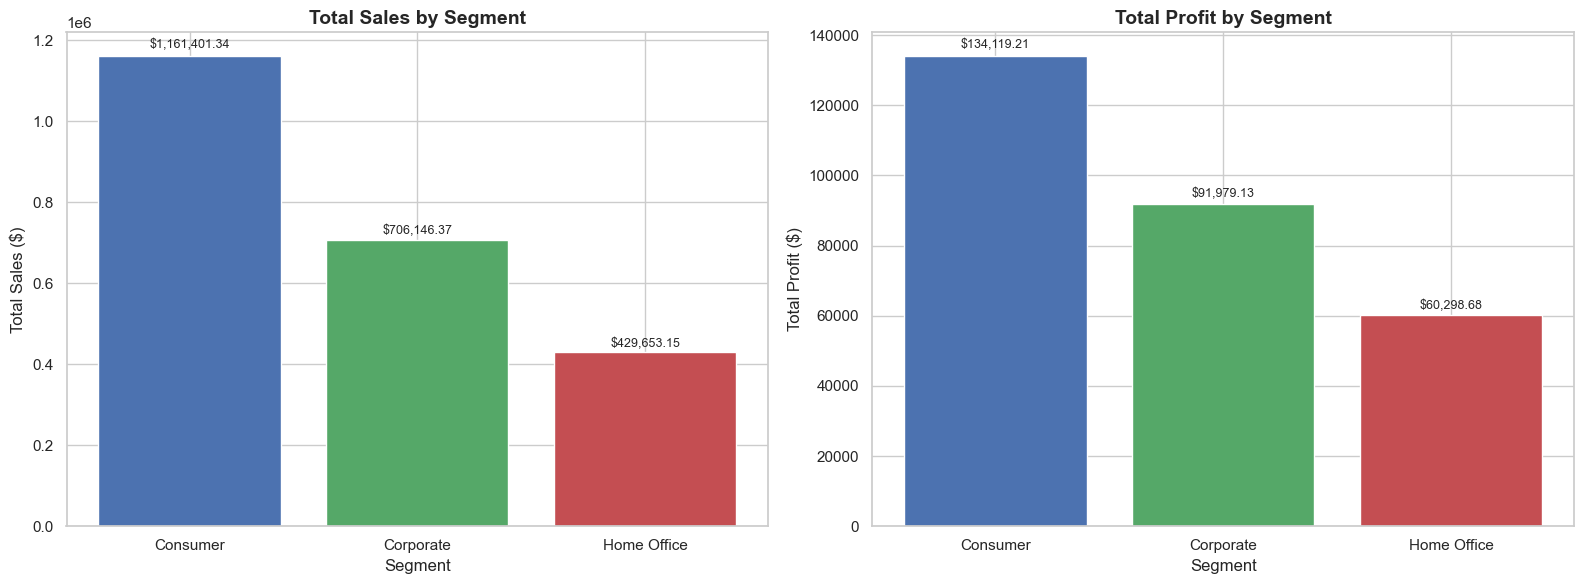

In [6]:
# VISUALIZE SALES AND PROFIT BY SEGMENT

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#4C72B0', '#55A868', '#C44E52']

# --- Sales ---
bars1 = axes[0].bar(
    segment_performance['Segment'],
    segment_performance['Total_Sales'],
    color=colors,
    edgecolor='white'
)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        format_currency(height),
        ha='center', va='bottom', fontsize=9
    )

axes[0].set_title('Total Sales by Segment',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Total Sales ($)')

# --- Profit ---
bars2 = axes[1].bar(
    segment_performance['Segment'],
    segment_performance['Total_Profit'],
    color=colors,
    edgecolor='white'
)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        format_currency(height),
        ha='center', va='bottom', fontsize=9
    )

axes[1].set_title('Total Profit by Segment',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Total Profit ($)')

plt.tight_layout()
save_fig('segment_sales_profit.png')
plt.show()

✅ Saved: images/segment_profit_margin.png


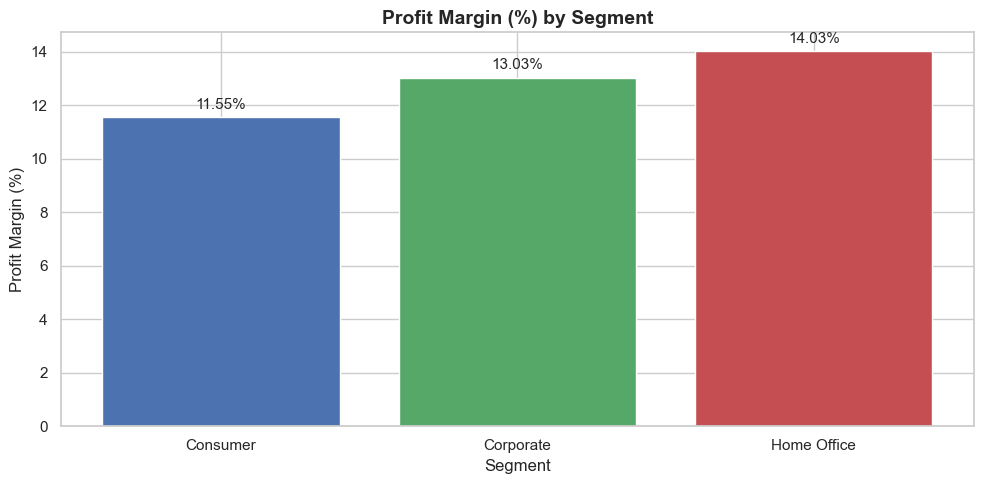

In [8]:
# ===== PROFIT MARGIN BY SEGMENT =====

plt.figure(figsize=(10, 5))

bars = plt.bar(
    segment_performance['Segment'],
    segment_performance['Profit_Margin_%'],
    color=colors,
    edgecolor='white'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        format_percent(height),
        ha='center', va='bottom', fontsize=11
    )

plt.title('Profit Margin (%) by Segment',
          fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Profit Margin (%)')

plt.tight_layout()
save_fig('segment_profit_margin.png')
plt.show()

✅ Saved: images/segment_sales_share_pie.png


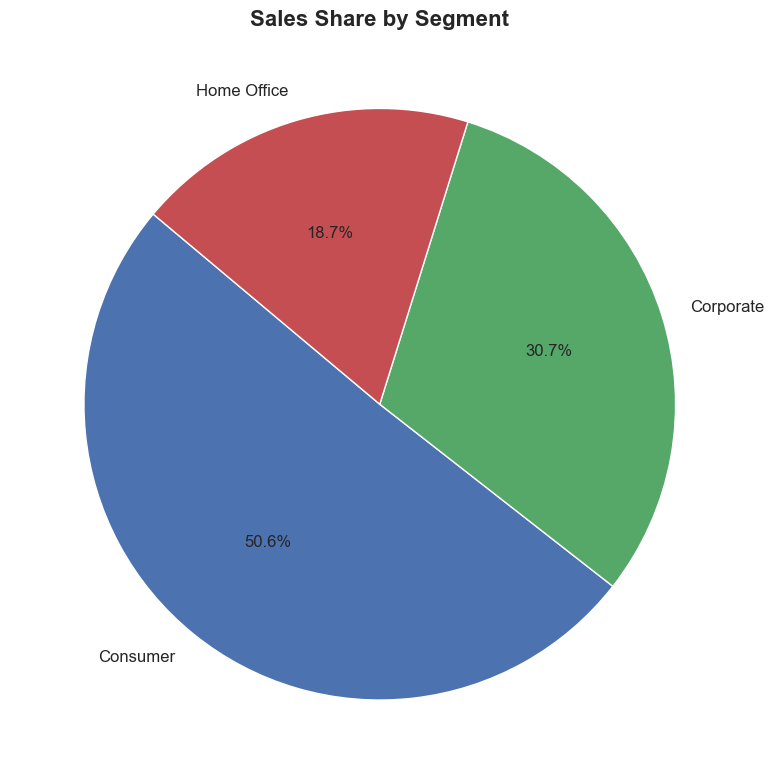

In [9]:
# SALES SHARE PIE CHART 

plt.figure(figsize=(8, 8))

plt.pie(
    segment_performance['Total_Sales'],
    labels=segment_performance['Segment'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    textprops={'fontsize': 12}
)

plt.title('Sales Share by Segment',
          fontsize=16, fontweight='bold')

plt.tight_layout()
save_fig('segment_sales_share_pie.png')
plt.show()

In [11]:
segment_performance.to_csv(
    'reports/tables/segment_performance.csv', index=False
)

print("Segment performance table saved")

Segment performance table saved


In [ ]:
### Insight



### Recommendation



## 2. Top 10 Customers by Sales

Business question:

**Who are the highest revenue-generating customers?**

In [12]:
# CUSTOMER PERFORMANCE

customer_performance = df.groupby(
    ['Customer ID', 'Customer Name', 'Segment']
).agg(
    Total_Sales    = ('Sales',    'sum'),
    Total_Profit   = ('Profit',   'sum'),
    Total_Orders   = ('Order ID', 'nunique'),
    Total_Quantity = ('Quantity', 'sum'),
    Avg_Discount   = ('Discount', 'mean')
).reset_index()

# Profit Margin
customer_performance['Profit_Margin_%'] = (
    customer_performance['Total_Profit'] /
    customer_performance['Total_Sales'] * 100
).round(2)

# Avg Order Value
customer_performance['Avg_Order_Value'] = (
    customer_performance['Total_Sales'] /
    customer_performance['Total_Orders']
).round(2)

# Avg Discount %
customer_performance['Avg_Discount_%'] = (
    customer_performance['Avg_Discount'] * 100
).round(2)

print(f"Total unique customers: {len(customer_performance)}")
customer_performance.head()

Total unique customers: 793


,Customer ID,Customer Name,Segment,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Avg_Discount,Profit_Margin_%,Avg_Order_Value,Avg_Discount_%
0,AA-10315,Alex Avila,Consumer,5563.56,-362.88,5,30,0.09,-6.52,1112.71,9.09
1,AA-10375,Allen Armold,Consumer,1056.39,277.38,9,41,0.08,26.26,117.38,8.00
2,AA-10480,Andrew Allen,Consumer,1790.51,435.83,4,36,0.02,24.34,447.63,1.67
3,AA-10645,Anna Andreadi,Consumer,5086.93,857.80,6,64,0.06,16.86,847.82,6.39
4,AB-10015,Aaron Bergman,Consumer,886.16,129.35,3,13,0.07,14.60,295.39,6.67


In [13]:
# TOP 10 CUSTOMERS BY SALES

top10_customers_sales = customer_performance.sort_values(
    'Total_Sales', ascending=False
).head(10).reset_index(drop=True)

top10_customers_sales[
    ['Customer Name', 'Segment', 'Total_Sales',
     'Total_Profit', 'Profit_Margin_%', 'Total_Orders']
]

,Customer Name,Segment,Total_Sales,Total_Profit,Profit_Margin_%,Total_Orders
0,Sean Miller,Home Office,25043.05,-1980.74,-7.91,5
1,Tamara Chand,Corporate,19052.22,8981.32,47.14,5
2,Raymond Buch,Consumer,15117.34,6976.10,46.15,6
3,Tom Ashbrook,Home Office,14595.62,4703.79,32.23,4
4,Adrian Barton,Consumer,14473.57,5444.81,37.62,10
5,Ken Lonsdale,Consumer,14175.23,806.86,5.69,12
6,Sanjit Chand,Consumer,14142.33,5757.41,40.71,9
7,Hunter Lopez,Consumer,12873.30,5622.43,43.68,6
8,Sanjit Engle,Consumer,12209.44,2650.68,21.71,11
9,Christopher Conant,Consumer,12129.07,2177.05,17.95,5


✅ Saved: images/top10_customers_by_sales.png


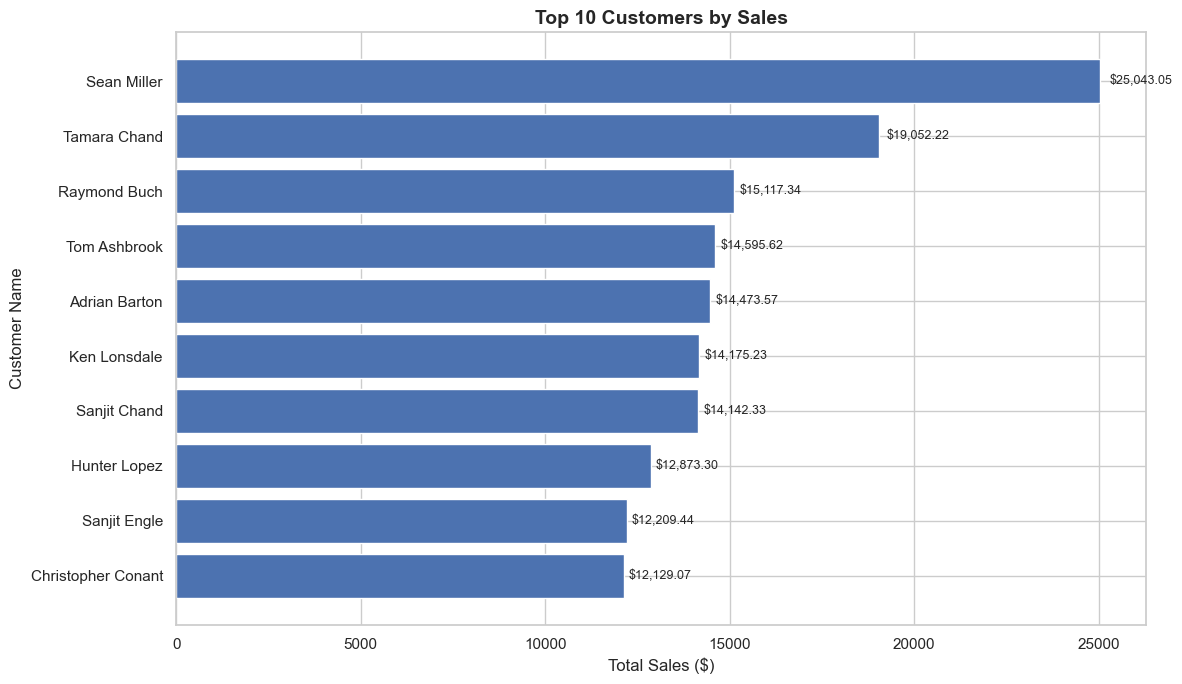

In [14]:
# VISUALIZE TOP 10 CUSTOMERS BY SALES

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top10_customers_sales['Customer Name'],
    top10_customers_sales['Total_Sales'],
    color='#4C72B0',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        format_currency(width),
        va='center', fontsize=9
    )

plt.title('Top 10 Customers by Sales',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer Name')
plt.gca().invert_yaxis()

plt.tight_layout()
save_fig('top10_customers_by_sales.png')
plt.show()

## 3. Top 10 Customers by Profit

Business question:

**Who are the most profitable customers?**

In [15]:
# TOP 10 CUSTOMERS BY PROFIT

top10_customers_profit = customer_performance.sort_values(
    'Total_Profit', ascending=False
).head(10).reset_index(drop=True)

top10_customers_profit[
    ['Customer Name', 'Segment', 'Total_Sales',
     'Total_Profit', 'Profit_Margin_%', 'Total_Orders']
]

,Customer Name,Segment,Total_Sales,Total_Profit,Profit_Margin_%,Total_Orders
0,Tamara Chand,Corporate,19052.22,8981.32,47.14,5
1,Raymond Buch,Consumer,15117.34,6976.10,46.15,6
2,Sanjit Chand,Consumer,14142.33,5757.41,40.71,9
3,Hunter Lopez,Consumer,12873.30,5622.43,43.68,6
4,Adrian Barton,Consumer,14473.57,5444.81,37.62,10
5,Tom Ashbrook,Home Office,14595.62,4703.79,32.23,4
6,Christopher Martinez,Consumer,8954.02,3899.89,43.55,4
7,Keith Dawkins,Corporate,8181.26,3038.63,37.14,12
8,Andy Reiter,Consumer,6608.45,2884.62,43.65,6
9,Daniel Raglin,Home Office,8350.87,2869.08,34.36,8


✅ Saved: images/top10_customers_by_profit.png


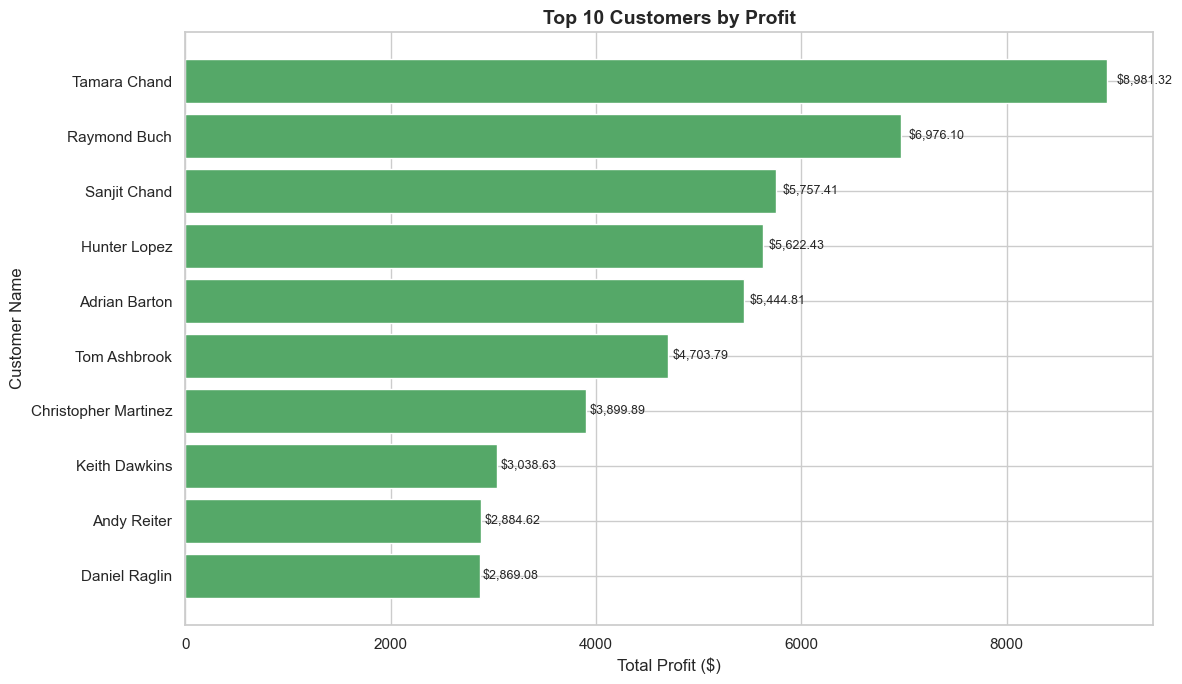

In [16]:
# VISUALIZE TOP 10 CUSTOMERS BY PROFIT

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top10_customers_profit['Customer Name'],
    top10_customers_profit['Total_Profit'],
    color='#55A868',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        format_currency(width),
        va='center', fontsize=9
    )

plt.title('Top 10 Customers by Profit',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Customer Name')
plt.gca().invert_yaxis()

plt.tight_layout()
save_fig('top10_customers_by_profit.png')
plt.show()

In [17]:
customer_performance.to_csv(
    'reports/tables/customer_performance.csv', index=False
)

top10_customers_sales.to_csv(
    'reports/tables/top10_customers_by_sales.csv', index=False
)

top10_customers_profit.to_csv(
    'reports/tables/top10_customers_by_profit.csv', index=False
)

print("Customer tables saved")

Customer tables saved


### Insight


### Recommendation



## 4. Customer Order Behavior

Business questions:

- **How many orders does an average customer place?**
- **What is the distribution of order values per customer?**

In [18]:
# CUSTOMER ORDER BEHAVIOR 

avg_orders = customer_performance['Total_Orders'].mean()
median_orders = customer_performance['Total_Orders'].median()
max_orders = customer_performance['Total_Orders'].max()
min_orders = customer_performance['Total_Orders'].min()

avg_order_value = customer_performance['Avg_Order_Value'].mean()
median_order_value = customer_performance['Avg_Order_Value'].median()

print("=" * 60)
print("CUSTOMER ORDER BEHAVIOR")
print("=" * 60)

print(f"\nOrders per Customer:")
print(f"  Average:  {avg_orders:.1f} orders")
print(f"  Median:   {median_orders:.1f} orders")
print(f"  Maximum:  {max_orders:.0f} orders")
print(f"  Minimum:  {min_orders:.0f} orders")

print(f"\nAverage Order Value per Customer:")
print(f"  Average:  {format_currency(avg_order_value)}")
print(f"  Median:   {format_currency(median_order_value)}")

CUSTOMER ORDER BEHAVIOR

Orders per Customer:
  Average:  6.3 orders
  Median:   6.0 orders
  Maximum:  17 orders
  Minimum:  1 orders

Average Order Value per Customer:
  Average:  $460.15
  Median:   $362.50


✅ Saved: images/customer_order_distribution.png


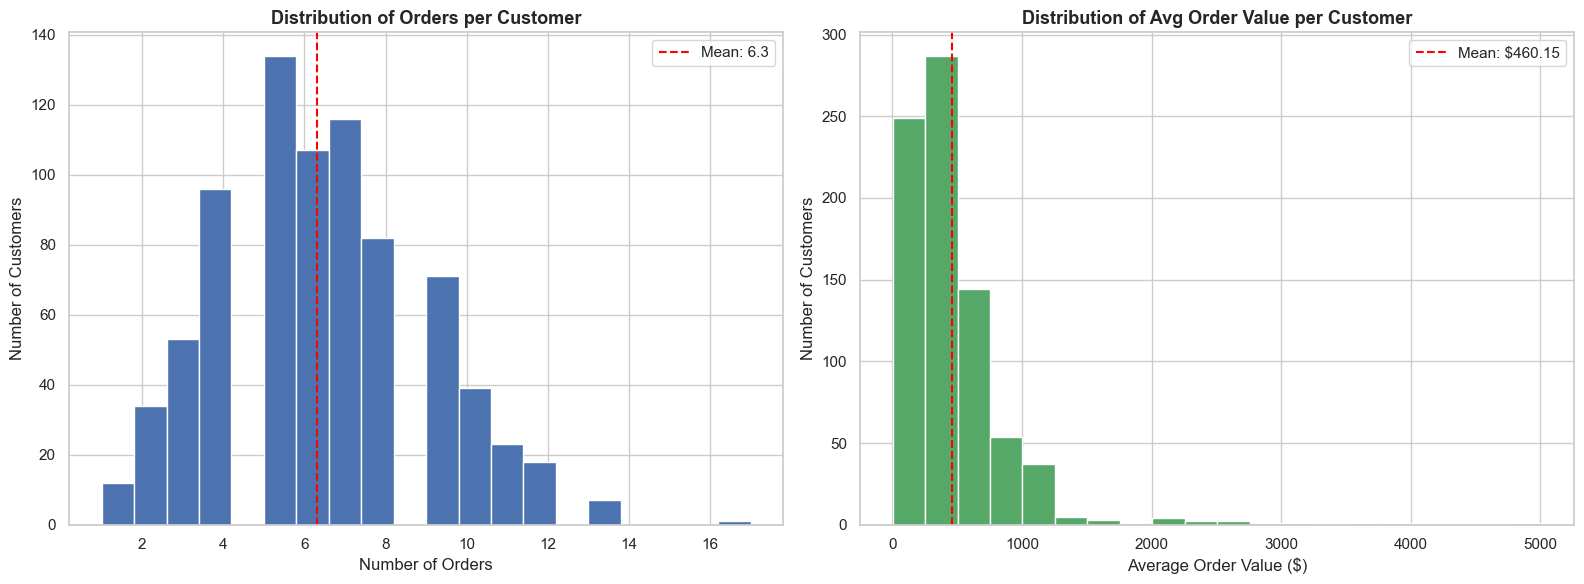

In [19]:
# ORDER DISTRIBUTION

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Orders per Customer ---
axes[0].hist(
    customer_performance['Total_Orders'],
    bins=20,
    color='#4C72B0',
    edgecolor='white'
)

axes[0].axvline(
    avg_orders,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean: {avg_orders:.1f}'
)

axes[0].set_title('Distribution of Orders per Customer',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# --- Avg Order Value per Customer ---
axes[1].hist(
    customer_performance['Avg_Order_Value'],
    bins=20,
    color='#55A868',
    edgecolor='white'
)

axes[1].axvline(
    avg_order_value,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean: {format_currency(avg_order_value)}'
)

axes[1].set_title('Distribution of Avg Order Value per Customer',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Order Value ($)')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.tight_layout()
save_fig('customer_order_distribution.png')
plt.show()

### Insight



### Recommendation



## 5. Customer Contribution Analysis

Business question:

**What percentage of customers contribute to the majority of sales?**

This analysis is inspired by the Pareto Principle (80/20 rule):
a small proportion of customers often generates 
the majority of revenue.

In [20]:
# CUSTOMER CONTRIBUTION (PARETO) 
# Sort by sales descending
customer_sorted = customer_performance.sort_values(
    'Total_Sales', ascending=False
).reset_index(drop=True)

# Cumulative sales
customer_sorted['Cumulative_Sales'] = (
    customer_sorted['Total_Sales'].cumsum()
)

customer_sorted['Cumulative_Sales_%'] = (
    customer_sorted['Cumulative_Sales'] /
    customer_sorted['Total_Sales'].sum() * 100
).round(2)

customer_sorted['Customer_Rank_%'] = (
    (customer_sorted.index + 1) /
    len(customer_sorted) * 100
).round(2)

# Find what % of customers = 80% of sales
threshold_80 = customer_sorted[
    customer_sorted['Cumulative_Sales_%'] <= 80
]

pct_customers_80 = (
    len(threshold_80) / len(customer_sorted) * 100
)

print("=" * 60)
print("CUSTOMER CONTRIBUTION ANALYSIS")
print("=" * 60)
print(f"\nTotal Customers: {len(customer_sorted):,}")
print(f"\nTop {pct_customers_80:.1f}% of customers "
      f"contribute 80% of total sales.")
print(f"That is {len(threshold_80):,} customers "
      f"out of {len(customer_sorted):,}.")

CUSTOMER CONTRIBUTION ANALYSIS

Total Customers: 793

Top 49.8% of customers contribute 80% of total sales.
That is 395 customers out of 793.


✅ Saved: images/customer_pareto_analysis.png


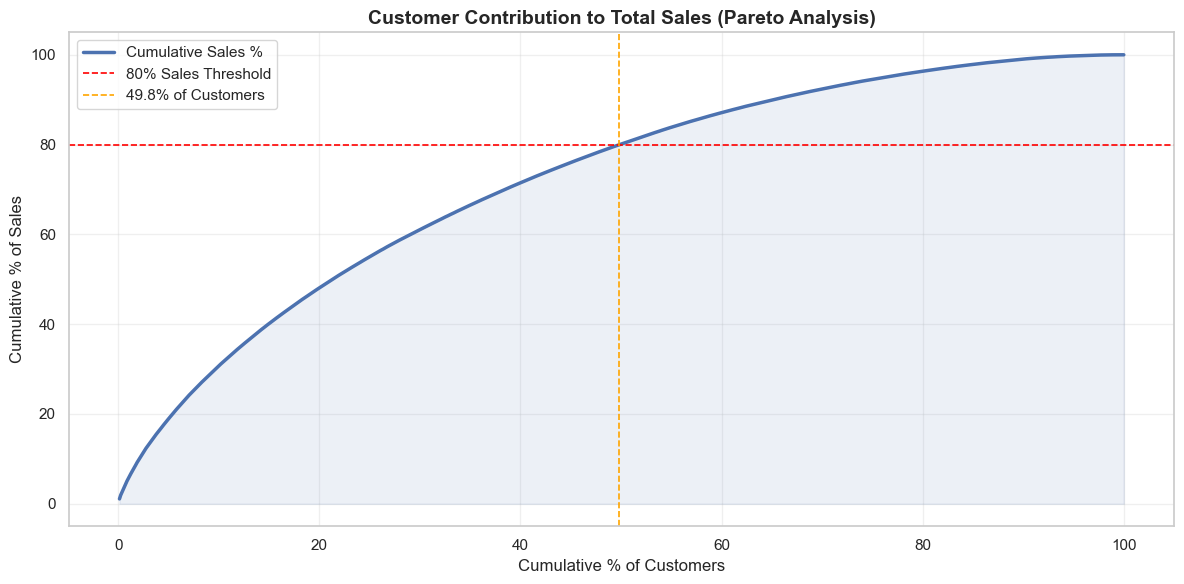

In [21]:
# PARETO CURVE 

plt.figure(figsize=(12, 6))

plt.plot(
    customer_sorted['Customer_Rank_%'],
    customer_sorted['Cumulative_Sales_%'],
    color='#4C72B0',
    linewidth=2.5,
    label='Cumulative Sales %'
)

# Reference lines
plt.axhline(80, color='red', linestyle='--',
            linewidth=1.2, label='80% Sales Threshold')
plt.axvline(pct_customers_80, color='orange',
            linestyle='--', linewidth=1.2,
            label=f'{pct_customers_80:.1f}% of Customers')

plt.fill_between(
    customer_sorted['Customer_Rank_%'],
    customer_sorted['Cumulative_Sales_%'],
    alpha=0.1,
    color='#4C72B0'
)

plt.title('Customer Contribution to Total Sales (Pareto Analysis)',
          fontsize=14, fontweight='bold')
plt.xlabel('Cumulative % of Customers')
plt.ylabel('Cumulative % of Sales')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
save_fig('customer_pareto_analysis.png')
plt.show()

In [ ]:
### Insight


### Recommendation



## 6. Segment Performance by Region

Business question:

**How does each customer segment perform across different regions?**

In [22]:
# SEGMENT x REGION PERFORMANCE

segment_region = df.groupby(['Region', 'Segment']).agg(
    Total_Sales   = ('Sales',    'sum'),
    Total_Profit  = ('Profit',   'sum'),
    Total_Orders  = ('Order ID', 'nunique')
).reset_index()

segment_region['Profit_Margin_%'] = (
    segment_region['Total_Profit'] /
    segment_region['Total_Sales'] * 100
).round(2)

segment_region

,Region,Segment,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%
0,Central,Consumer,252031.43,8564.05,604,3.40
1,Central,Corporate,157995.81,18703.90,348,11.84
2,Central,Home Office,91212.64,12438.41,223,13.64
3,East,Consumer,350908.17,41190.98,713,11.74
4,East,Corporate,200409.35,23622.58,434,11.79
5,East,Home Office,127463.73,26709.22,254,20.95
6,South,Consumer,195580.97,26913.57,444,13.76
7,South,Corporate,121885.93,15215.22,247,12.48
8,South,Home Office,74255.00,4620.63,131,6.22
9,West,Consumer,362880.77,57450.60,825,15.83


✅ Saved: images/segment_region_performance.png


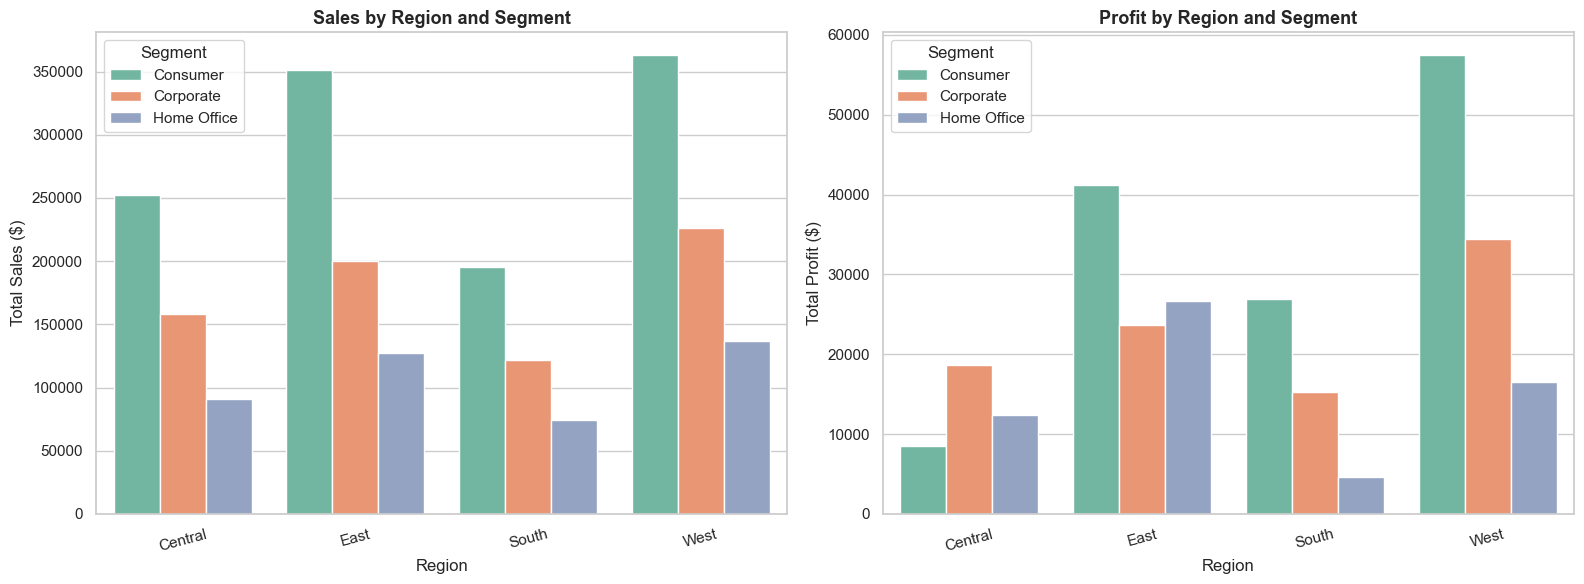

In [23]:
# VISUALIZE SEGMENT x REGION

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales
sns.barplot(
    data=segment_region,
    x='Region',
    y='Total_Sales',
    hue='Segment',
    ax=axes[0],
    palette='Set2'
)

axes[0].set_title('Sales by Region and Segment',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Segment')

# Profit
sns.barplot(
    data=segment_region,
    x='Region',
    y='Total_Profit',
    hue='Segment',
    ax=axes[1],
    palette='Set2'
)

axes[1].set_title('Profit by Region and Segment',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Profit ($)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Segment')

plt.tight_layout()
save_fig('segment_region_performance.png')
plt.show()

In [24]:
segment_region.to_csv(
    'reports/tables/segment_region_performance.csv', index=False
)

customer_sorted[[
    'Customer ID', 'Customer Name', 'Segment',
    'Total_Sales', 'Total_Profit',
    'Cumulative_Sales_%', 'Customer_Rank_%'
]].to_csv(
    'reports/tables/customer_pareto.csv', index=False
)

print("Segment x Region and Pareto tables saved")

Segment x Region and Pareto tables saved


In [ ]:
### Insight



### Recommendation



## 7. Final Summary

In [25]:
# FINAL SUMMARY

best_segment_sales  = segment_performance.iloc[0]
best_segment_profit = segment_performance.sort_values(
    'Total_Profit', ascending=False).iloc[0]
best_segment_margin = segment_performance.sort_values(
    'Profit_Margin_%', ascending=False).iloc[0]

best_customer_sales  = top10_customers_sales.iloc[0]
best_customer_profit = top10_customers_profit.iloc[0]

print("=" * 60)
print("CUSTOMER ANALYSIS SUMMARY")
print("=" * 60)

print(f"\n👥 SEGMENT")
print(f"  Highest Sales:   {best_segment_sales['Segment']} "
      f"({format_currency(best_segment_sales['Total_Sales'])})")
print(f"  Highest Profit:  {best_segment_profit['Segment']} "
      f"({format_currency(best_segment_profit['Total_Profit'])})")
print(f"  Best Margin:     {best_segment_margin['Segment']} "
      f"({format_percent(best_segment_margin['Profit_Margin_%'])})")

print(f"\n🏆 TOP CUSTOMERS")
print(f"  Top by Sales:   {best_customer_sales['Customer Name']} "
      f"({format_currency(best_customer_sales['Total_Sales'])})")
print(f"  Top by Profit:  {best_customer_profit['Customer Name']} "
      f"({format_currency(best_customer_profit['Total_Profit'])})")

print(f"\n📊 ORDER BEHAVIOR")
print(f"  Avg Orders/Customer:     {avg_orders:.1f}")
print(f"  Avg Order Value:         {format_currency(avg_order_value)}")
print(f"  Total Unique Customers:  {format_number(len(customer_performance))}")

print(f"\n📈 PARETO")
print(f"  Top {pct_customers_80:.1f}% of customers "
      f"= 80% of total sales")


CUSTOMER ANALYSIS SUMMARY

👥 SEGMENT
  Highest Sales:   Consumer ($1,161,401.34)
  Highest Profit:  Consumer ($134,119.21)
  Best Margin:     Home Office (14.03%)

🏆 TOP CUSTOMERS
  Top by Sales:   Sean Miller ($25,043.05)
  Top by Profit:  Tamara Chand ($8,981.32)

📊 ORDER BEHAVIOR
  Avg Orders/Customer:     6.3
  Avg Order Value:         $460.15
  Total Unique Customers:  793

📈 PARETO
  Top 49.8% of customers = 80% of total sales


## Summary

In this notebook, we analyzed customer behavior and 
performance across segments and individual customers.

### Key Areas Covered
- Segment-level sales and profit performance
- Top 10 customers by sales and profit
- Customer order behavior and distribution
- Pareto analysis of customer contribution
- Segment performance across regions

### Main Takeaways
- A small group of customers contributes 
  the majority of total sales revenue.
- Segment profitability differs from segment 
  revenue volume — both must be evaluated together.
- Customer retention for top accounts is critical 
  to revenue stability.

### Next Step
Notebook 06 will focus on **Discount and Profitability Analysis**, 
including:
- Impact of discounts on profit
- Discount levels and their effect on profitability
- Categories most affected by discounting
- Recommendations for discount strategy